In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set which one-hot sample to compare (0-4)
# 0: corner (0,0)
# 1: corner (47,47)
# 2: center (24,24)
# 3: top edge (0,24)
# 4: left edge (24,0)
TEST_NUM = "populated0"

In [3]:
def load_rtl_layer(path, nfrac):
    raw = np.loadtxt(path, delimiter=',')   # shape (n_positions, n_channels)
    flat = raw.flatten()                     # row-major: channel varies fastest, matches (H,W,C) flatten
    return flat / (2 ** nfrac)

def load_ref_layer(path):
    return np.loadtxt(path, delimiter=',')   # already flat, already decimal

# every layer in pipeline order:
#   (short name, rtl filename suffix, hls4ml filename suffix, nfrac)
LAYER_SPECS = [
    ("conv0",  "conv0",  "q_activation",    6),
    ("pool0",  "pool0",  "max_pooling2d",   6),
    ("conv1",  "conv1",  "q_activation_1",  5),
    ("pool1",  "pool1",  "max_pooling2d_1", 5),
    ("conv2",  "conv2",  "q_activation_2",  5),
    ("pool2",  "pool2",  "max_pooling2d_2", 5),
    ("dense0", "dense0", "q_dense",         5),
    ("relu0",  "relu0",  "q_activation_3",  5),
    ("dense1", "dense1", "q_dense_1",       5),
    ("relu1",  "relu1",  "q_activation_4",  5),
    ("final",  "final",  "q_dense_2",       5),
]

def rtl_path(test_num, suffix):
    return f"populated_traces/rtl_{test_num}_{suffix}.csv"

def hls_path(test_num, suffix):
    return f"traces/hls4ml_{test_num}_{suffix}.csv"

def keras_path(test_num, suffix):
    return f"traces/keras_{test_num}_{suffix}.csv"

In [4]:
def diff_stats(rtl_p, ref_p, nfrac, label=None, outlier_threshold=0.1):
    rtl = load_rtl_layer(rtl_p, nfrac)
    ref = load_ref_layer(ref_p)
    n = min(len(rtl), len(ref))
    diff = np.abs(rtl[:n] - ref[:n])
    stats = {
        "label": label or ref_p, "mean": diff.mean(), "median": np.median(diff),
        "p95": np.percentile(diff, 95), "max": diff.max(),
        "outliers": int((diff > outlier_threshold).sum()), "n": diff.size,
    }
    print(f"{stats['label']:12s} mean={stats['mean']:.6f} median={stats['median']:.6f} "
          f"p95={stats['p95']:.6f} max={stats['max']:.6f} outliers={stats['outliers']}/{stats['n']} (>{outlier_threshold})")
    return stats

def run_full_comparison(test_num, ref_source="hls4ml"):
    print(f"=== TEST_NUM={test_num} ===")
    results = []
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        results.append(diff_stats(rtl_path(test_num, rtl_suffix), hls_path(test_num, hls_suffix), nfrac, label=name))
    return results

In [5]:
import contextlib
import io

buf = io.StringIO()

with contextlib.redirect_stdout(buf):
    results_by_test = {}
    # for test_num in range(5):
    #     results_by_test[test_num] = run_full_comparison(test_num)
    for label in ["populated0", "populated1", "populated2"]:
        print(f"\n{'='*70}\n{label}\n{'='*70}")
        results_by_test[label] = run_full_comparison(label)

# attach ULP figures using each layer's own nfrac (quantization step size)
nfrac_by_label = {name: nfrac for name, _, _, nfrac in LAYER_SPECS}
for results in results_by_test.values():
    for r in results:
        nfrac = nfrac_by_label[r["label"]]
        r["max_ulp"] = r["max"] * (2 ** nfrac)
        r["mean_ulp"] = r["mean"] * (2 ** nfrac)

positions = {
    0: "Corner (0,0)",
    1: "Corner (47,47)",
    2: "Center (24,24)",
    3: "Top edge (0,24)",
    4: "Left edge (24,0)",
}

OUTLIER_THRESHOLD = 0.1  # must match the threshold used in diff_stats/run_full_comparison
outlier_col = f"Outliers(>{OUTLIER_THRESHOLD})"

lines = []
lines.append("RTL vs. HLS4ML Comparison")
lines.append("-" * 70)
lines.append("")
lines.append("Final Output Layer: All Test Positions")
lines.append("-" * 70)
lines.append(f"{'Test Position':<20}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
for test_num, results in results_by_test.items():
    f = results[-1]
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append(f"{pos_label:<20}{f['mean']:>10.6f}{f['mean_ulp']:>11.2f}{f['max']:>10.6f}{f['max_ulp']:>10.2f}{f['outliers']:>13d}/{f['n']}")

# per-layer breakdown for EVERY test position, not just one
for test_num, results in results_by_test.items():
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append("")
    lines.append(f"Per-Layer Breakdown (Test {test_num}: {pos_label})")
    lines.append("-" * 70)
    lines.append(f"{'Layer':<12}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
    for r in results:
        lines.append(f"{r['label']:<12}{r['mean']:>10.6f}{r['mean_ulp']:>11.2f}{r['max']:>10.6f}{r['max_ulp']:>10.2f}{r['outliers']:>13d}/{r['n']}")

report_text = "\n".join(lines)
print(report_text)

with open("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/final_results_summary.txt", "w") as f:
    f.write(report_text)

RTL vs. HLS4ML Comparison
----------------------------------------------------------------------

Final Output Layer: All Test Positions
----------------------------------------------------------------------
Test Position         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
Test populated0       0.093750       3.00  0.125000      4.00            3/5
Test populated1       0.118750       3.80  0.187500      6.00            2/5
Test populated2       0.093750       3.00  0.156250      5.00            2/5

Per-Layer Breakdown (Test populated0: Test populated0)
----------------------------------------------------------------------
Layer         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
conv0         0.000620       0.04  0.078125      5.00            0/12684
pool0         0.001227       0.08  0.078125      5.00            0/726
conv1         0.039062       1.25  1.000000     32.00           68/648
pool1         0.083496       2.67  1.000000     32.00           23/128


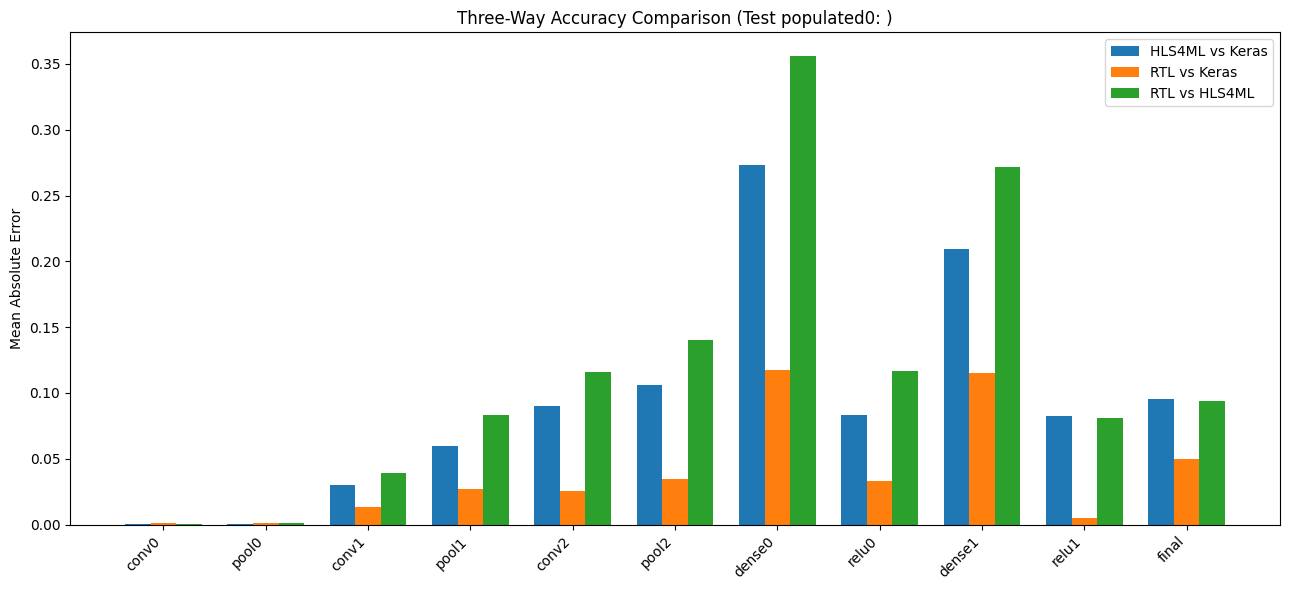

In [6]:
def plot_three_way_comparison(test_num):
    # gather all three comparisons for this test
    hls_vs_keras = []
    rtl_vs_keras = []
    rtl_vs_hls = []

    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_num, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_num, hls_suffix))
        keras = load_ref_layer(keras_path(test_num, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        hls_vs_keras.append(np.abs(hls[:n] - keras[:n]).mean())
        rtl_vs_keras.append(np.abs(rtl[:n] - keras[:n]).mean())
        rtl_vs_hls.append(np.abs(rtl[:n] - hls[:n]).mean())

    names = [name for name, _, _, _ in LAYER_SPECS]
    x = np.arange(len(names))
    width = 0.25

    plt.figure(figsize=(13, 6))
    plt.bar(x - width, hls_vs_keras, width, label='HLS4ML vs Keras')
    plt.bar(x, rtl_vs_keras, width, label='RTL vs Keras')
    plt.bar(x + width, rtl_vs_hls, width, label='RTL vs HLS4ML')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'Three-Way Accuracy Comparison (Test {test_num}: {positions.get(test_num, "")})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_three_way_comparison("populated0")  

In [7]:
r = load_rtl_layer(rtl_path("populated0", "dense0"), 5)
h = load_ref_layer(hls_path("populated0", "q_dense"))
diff = np.abs(r - h)
worst = np.argmax(diff)
print(f"worst dense0 output index: {worst}, rtl={r[worst]}, hls4ml={h[worst]}, diff={diff[worst]}")

worst dense0 output index: 6, rtl=-1.15625, hls4ml=-0.28125, diff=0.875


In [8]:
import tensorflow as tf
from qkeras import QConv2DBatchnorm, QActivation, QDense
from qkeras.utils import _add_supported_quantized_objects

def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

co = {}
_add_supported_quantized_objects(co)
co["dice_loss"] = dice_loss

model = tf.keras.models.load_model(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/Models/gaussian_nov24.keras",
    custom_objects=co
)
model.summary()

2026-09-22 05:39:27.229184: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-22 05:39:27.438853: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/aya/local_libs:
2026-09-22 05:39:27.438893: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-09-22 05:39:28.494345: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared obje

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Model: "pp_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_conv2d_batchnorm (QConv2D  (None, 46, 46, 6)        85        
 Batchnorm)                                                      
                                                                 
 q_activation (QActivation)  (None, 46, 46, 6)         0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 6)        0         
 )                                                               
                                                                 
 q_conv2d_batchnorm_1 (QConv  (None, 9, 9, 8)          473       
 2DBatchnorm)                                                    
                                                                 
 q_activation_1 (QActivation  (None, 9, 9, 8)          0         
 )                                                        

In [9]:
layer_dense0 = model.get_layer("q_dense")
weights_dense0 = layer_dense0.get_weights()
print("number of weight arrays:", len(weights_dense0))
print("kernel shape:", weights_dense0[0].shape)
print("bias shape:", weights_dense0[1].shape)

number of weight arrays: 2
kernel shape: (10, 15)
bias shape: (15,)


In [10]:
flatten_raw = np.loadtxt(rtl_path("populated0", "pool2"), delimiter=',').flatten()
print("flatten_raw shape:", flatten_raw.shape)  # should be 10*1*1 = 10 (from pool2's OUTPUT_CHANNELS_CONV2=10, POOL2_OUT_WIDTH=1)

flatten_raw shape: (10,)


In [11]:
Nfrac_weight_dense0 = 5
Nfrac_input_dense0 = 5

out_idx = 6
weight_col = weights_dense0[0][:, out_idx]
bias_val = float(weights_dense0[1][out_idx])

total = 0
for in_idx in range(10):
    weight_int = round(float(weight_col[in_idx]) * (2**Nfrac_weight_dense0))
    pixel_int = int(flatten_raw[in_idx])
    total += (pixel_int * weight_int) >> Nfrac_input_dense0

bias_int = round(bias_val * (2**Nfrac_weight_dense0))
expected_raw = total + bias_int
print("expected raw output:", expected_raw)
print("expected decimal:", expected_raw / (2**Nfrac_weight_dense0))

rtl_raw = int(np.loadtxt(rtl_path("populated0", "dense0"), delimiter=',').flatten()[6])
print("actual RTL raw:", rtl_raw, "-> decimal:", rtl_raw / (2**Nfrac_weight_dense0))

expected raw output: -37
expected decimal: -1.15625
actual RTL raw: -37 -> decimal: -1.15625


In [12]:
import pandas as pd

keras_vs_hls = {}
keras_vs_rtl = {}
hls_vs_rtl = {}

rows = []
for test_label in ["populated0", "populated1", "populated2"]:
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_label, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_label, hls_suffix))
        keras = load_ref_layer(keras_path(test_label, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        rtl_n, hls_n, keras_n = rtl[:n], hls[:n], keras[:n]

        d_hk = np.abs(hls_n - keras_n)
        d_kr = np.abs(keras_n - rtl_n)
        d_hr = np.abs(hls_n - rtl_n)

        rows.append({
            "test": test_label,
            "layer": name,
            "n": n,
            "keras_vs_hls_mean": d_hk.mean(),
            "keras_vs_hls_max": d_hk.max(),
            "keras_vs_rtl_mean": d_kr.mean(),
            "keras_vs_rtl_max": d_kr.max(),
            "hls_vs_rtl_mean": d_hr.mean(),
            "hls_vs_rtl_max": d_hr.max(),
        })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")
print(df.to_string(index=False))

df.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/three_way_comparison.csv", index=False)

      test  layer     n  keras_vs_hls_mean  keras_vs_hls_max  keras_vs_rtl_mean  keras_vs_rtl_max  hls_vs_rtl_mean  hls_vs_rtl_max
populated0  conv0 12684            0.00022           0.03125            0.00084           0.09375          0.00062         0.07812
populated0  pool0   726            0.00030           0.03125            0.00153           0.09375          0.00123         0.07812
populated0  conv1   648            0.03024           0.64062            0.01355           0.35938          0.03906         1.00000
populated0  pool1   128            0.05969           0.64062            0.02722           0.35938          0.08350         1.00000
populated0  conv2    40            0.08984           0.68750            0.02578           0.28125          0.11563         0.71875
populated0  pool2    10            0.10625           0.64062            0.03438           0.26562          0.14062         0.71875
populated0 dense0    15            0.27344           0.69580            0.11784    

In [13]:
test_labels = [f"populated{i}" for i in range(15)]

rows = []
for test_label in test_labels:
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_label, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_label, hls_suffix))
        keras = load_ref_layer(keras_path(test_label, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        rtl_n, hls_n, keras_n = rtl[:n], hls[:n], keras[:n]

        rows.append({
            "test": test_label, "layer": name, "n": n,
            "keras_vs_hls_mean": np.abs(hls_n - keras_n).mean(),
            "keras_vs_rtl_mean": np.abs(keras_n - rtl_n).mean(),
            "hls_vs_rtl_mean": np.abs(hls_n - rtl_n).mean(),
        })

df = pd.DataFrame(rows)
df.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/three_way_comparison_15.csv", index=False)

# quick aggregate: does the "RTL closer to Keras than hls4ml is" pattern hold across all 15?
final_rows = df[df["layer"] == "final"]
print(final_rows[["test", "keras_vs_hls_mean", "keras_vs_rtl_mean"]])
print()
print("RTL closer to Keras than hls4ml in", (final_rows["keras_vs_rtl_mean"] < final_rows["keras_vs_hls_mean"]).sum(), "/ 15 tests")

            test  keras_vs_hls_mean  keras_vs_rtl_mean
10    populated0            0.09551            0.04980
21    populated1            0.10176            0.01836
32    populated2            0.09248            0.04209
43    populated3            0.14053            0.02705
54    populated4            0.08633            0.02617
65    populated5            0.11006            0.02998
76    populated6            0.10811            0.04307
87    populated7            0.13457            0.04824
98    populated8            0.05078            0.02129
109   populated9            0.12852            0.02422
120  populated10            0.11016            0.05234
131  populated11            0.11514            0.01611
142  populated12            0.11445            0.05332
153  populated13            0.12061            0.02080
164  populated14            0.08291            0.01924

RTL closer to Keras than hls4ml in 15 / 15 tests


In [14]:
image_list = [f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/gaussian_test_data/populated_{i}.txt" for i in range(15)]

with open("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/gaussian_test_data/image_list.txt", "w") as f:
    for path in image_list:
        f.write(path + "\n")

In [15]:
rtl_stream = np.loadtxt("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/streaming_traces/rtl_streaming_final.csv", delimiter=',')

Nfrac_final = 5
print(f"{'image':>6s}  {'mean_diff':>10s}  {'max_diff':>10s}")
for row in rtl_stream:
    idx = int(row[0])
    rtl_decimal = row[1:] / (2**Nfrac_final)
    hls = load_ref_layer(hls_path(f"populated{idx}", "q_dense_2"))
    diff = np.abs(rtl_decimal - hls)
    print(f"{idx:>6d}  {diff.mean():>10.5f}  {diff.max():>10.5f}")

 image   mean_diff    max_diff
     0     0.09375     0.12500
     1     0.07500     0.12500
     2     0.15000     0.25000
     3     0.13125     0.21875
     4     0.05625     0.09375
     5     0.01875     0.03125
     6     0.07500     0.12500
     7     0.12500     0.21875
     8     0.05625     0.09375
     9     0.10000     0.12500
    10     0.10000     0.18750
    11     0.09375     0.12500
    12     0.09375     0.15625
    13     0.09375     0.12500
    14     0.01875     0.06250


In [16]:
print(f"{'image':>6s}  {'mean_ulp':>10s}  {'max_ulp':>10s}")
for row in rtl_stream:
    idx = int(row[0])
    rtl_decimal = row[1:] / (2**Nfrac_final)
    hls = load_ref_layer(hls_path(f"populated{idx}", "q_dense_2"))
    diff = np.abs(rtl_decimal - hls)
    print(f"{idx:>6d}  {diff.mean()*32:>10.2f}  {diff.max()*32:>10.2f}")

 image    mean_ulp     max_ulp
     0        3.00        4.00
     1        2.40        4.00
     2        4.80        8.00
     3        4.20        7.00
     4        1.80        3.00
     5        0.60        1.00
     6        2.40        4.00
     7        4.00        7.00
     8        1.80        3.00
     9        3.20        4.00
    10        3.20        6.00
    11        3.00        4.00
    12        3.00        5.00
    13        3.00        4.00
    14        0.60        2.00


In [20]:
Nfrac_final = 5

rtl_stream = np.loadtxt("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/streaming_traces/rtl_streaming_final.csv", delimiter=',')

rows = []
for row in rtl_stream:
    idx = int(row[0])
    rtl_stream_decimal = row[1:] / (2**Nfrac_final)

    rtl_single_raw = np.loadtxt(f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/populated_traces/rtl_populated{idx}_final.csv", delimiter=',')
    rtl_single_decimal = rtl_single_raw / (2**Nfrac_final)

    hls = load_ref_layer(hls_path(f"populated{idx}", "q_dense_2"))
    keras = load_ref_layer(keras_path(f"populated{idx}", "q_dense_2"))

    keras_vs_stream = np.abs(keras - rtl_stream_decimal).mean()
    keras_vs_single = np.abs(keras - rtl_single_decimal).mean()
    keras_vs_hls    = np.abs(keras - hls).mean()
    hls_vs_stream   = np.abs(hls - rtl_stream_decimal).mean()
    hls_vs_single   = np.abs(hls - rtl_single_decimal).mean()

    rows.append({
        "test": f"populated{idx}",
        "keras_vs_hls":    keras_vs_hls,
        "keras_vs_stream": keras_vs_stream,
        "keras_vs_single": keras_vs_single,
        "hls_vs_stream":   hls_vs_stream,
        "hls_vs_single":   hls_vs_single,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print()
print("Streaming closer to Keras than HLS4ML:", (df["keras_vs_stream"] < df["keras_vs_hls"]).sum(), "/ 15")
print("Single closer to Keras than HLS4ML:   ", (df["keras_vs_single"] < df["keras_vs_hls"]).sum(), "/ 15")
print("Streaming closer to Keras than Single:", (df["keras_vs_stream"] < df["keras_vs_single"]).sum(), "/ 15")

df.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/full_five_way_comparison.csv", index=False)

       test  keras_vs_hls  keras_vs_stream  keras_vs_single  hls_vs_stream  hls_vs_single
 populated0       0.09551          0.04980          0.04980        0.09375        0.09375
 populated1       0.10176          0.07090          0.01836        0.07500        0.11875
 populated2       0.09248          0.07686          0.04209        0.15000        0.09375
 populated3       0.14053          0.07822          0.02705        0.13125        0.16250
 populated4       0.08633          0.06367          0.02617        0.05625        0.07500
 populated5       0.11006          0.11748          0.02998        0.01875        0.11875
 populated6       0.10811          0.05557          0.04307        0.07500        0.11250
 populated7       0.13457          0.07988          0.04824        0.12500        0.14375
 populated8       0.05078          0.01699          0.02129        0.05625        0.06250
 populated9       0.12852          0.11152          0.02422        0.10000        0.13750
populated1

In [24]:
import re

def extract_top_level_util(file, top_names=("myproject", "rheedGaussianWrapper")):
    with open(file) as f:
        text = f.read()
    pattern = (
        r"\|\s*(" + "|".join(top_names) + r")\s*\|\s*\(top\)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
        r"\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
    )
    m = re.search(pattern, text)
    if m:
        return {
            "Total LUTs": int(m.group(2)), "Logic LUTs": int(m.group(3)),
            "LUTRAMs": int(m.group(4)), "SRLs": int(m.group(5)),
            "FFs": int(m.group(6)), "RAMB36": int(m.group(7)),
            "RAMB18": int(m.group(8)), "URAM": int(m.group(9)), "DSP48": int(m.group(10)),
        }
    return None

handmade_util = extract_top_level_util(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt"
)
hls_util = extract_top_level_util(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt"
)
print("Handmade:", handmade_util)
print("HLS4ML:  ", hls_util)

Handmade: {'Total LUTs': 20079, 'Logic LUTs': 19790, 'LUTRAMs': 160, 'SRLs': 129, 'FFs': 6657, 'RAMB36': 0, 'RAMB18': 0, 'URAM': 0, 'DSP48': 0}
HLS4ML:   {'Total LUTs': 25507, 'Logic LUTs': 23979, 'LUTRAMs': 0, 'SRLs': 1528, 'FFs': 15798, 'RAMB36': 18, 'RAMB18': 56, 'URAM': 0, 'DSP48': 0}


In [31]:
handmade_timing = extract_timing_summary(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_timing.rpt"
)
hls_timing = extract_timing_summary(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hsl4ml_timing.rpt"
)
print("Handmade timing:", handmade_timing)
print("HLS4ML timing:  ", hls_timing)

Handmade timing: {'WNS': -2.905, 'TNS': -1356.311}
HLS4ML timing:   {'WNS': 0.254, 'TNS': 0.0}


In [32]:
summary = pd.DataFrame([
    {
        "Design": "Handmade RTL", "Bits": 8,
        **handmade_util,
        "WNS (ns)": handmade_timing["WNS"] if handmade_timing else None,
        "Latency (cycles)": 19225,
        "Streaming Throughput (cycles/img)": 19349,
        "Mean Abs Error vs Keras": df["keras_vs_single"].mean() if "df" in dir() else None,
    },
    {
        "Design": "HLS4ML", "Bits": 8,
        **hls_util,
        "WNS (ns)": hls_timing["WNS"] if hls_timing else None,
        "Latency (cycles)": None,
        "Streaming Throughput (cycles/img)": None,
        "Mean Abs Error vs Keras": df["keras_vs_hls"].mean() if "df" in dir() else None,
    },
])
print(summary.to_string(index=False))
summary.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/caroline_style_final_summary.csv", index=False)

      Design  Bits  Total LUTs  Logic LUTs  LUTRAMs  SRLs   FFs  RAMB36  RAMB18  URAM  DSP48  WNS (ns)  Latency (cycles)  Streaming Throughput (cycles/img)  Mean Abs Error vs Keras
Handmade RTL     8       20079       19790      160   129  6657       0       0     0      0  -2.90500       19225.00000                        19349.00000                  0.03281
      HLS4ML     8       25507       23979        0  1528 15798      18      56     0      0   0.25400               NaN                                NaN                  0.10613


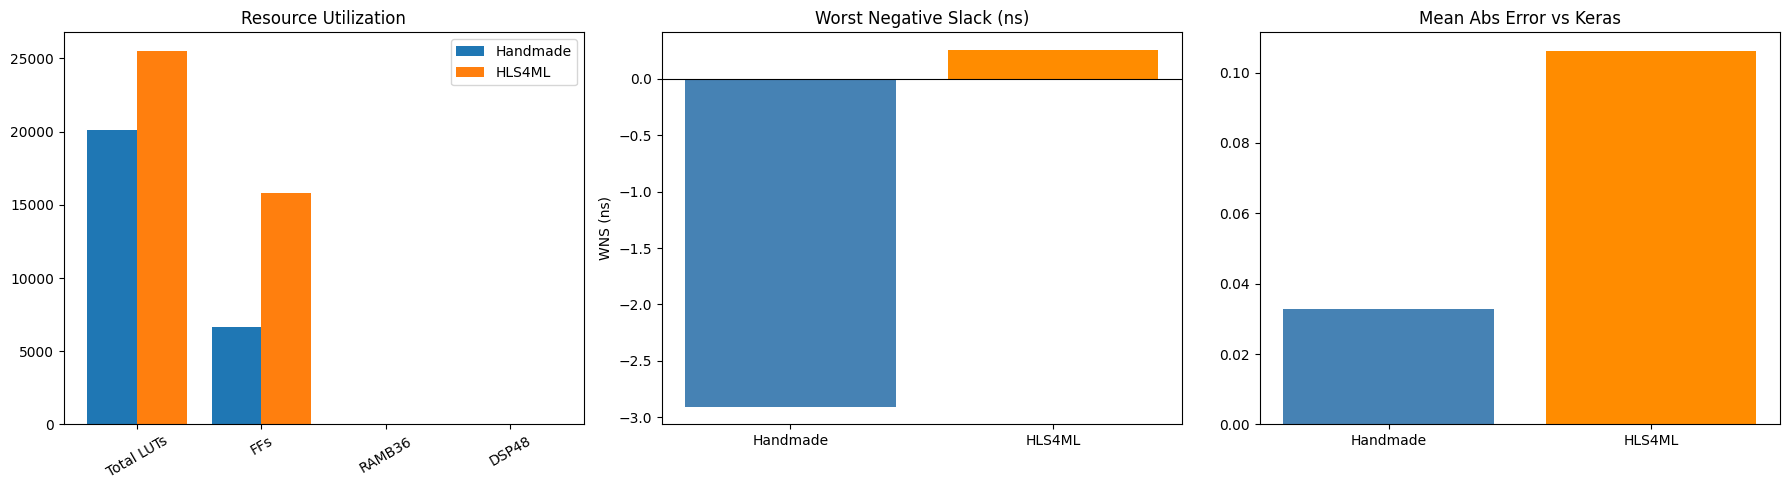

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: resource utilization
metrics = ["Total LUTs", "FFs", "RAMB36", "DSP48"]
h_vals = [handmade_util[m] for m in metrics]
s_vals = [hls_util[m] for m in metrics]
x = np.arange(len(metrics))
axes[0].bar(x - 0.2, h_vals, 0.4, label="Handmade")
axes[0].bar(x + 0.2, s_vals, 0.4, label="HLS4ML")
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, rotation=30)
axes[0].set_title("Resource Utilization"); axes[0].legend()

# panel 2: timing / WNS
axes[1].bar(["Handmade", "HLS4ML"], [handmade_timing["WNS"], hls_timing["WNS"]], color=["steelblue","darkorange"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Worst Negative Slack (ns)"); axes[1].set_ylabel("WNS (ns)")

# panel 3: accuracy
axes[2].bar(["Handmade", "HLS4ML"],
            [df["keras_vs_single"].mean(), df["keras_vs_hls"].mean()],
            color=["steelblue","darkorange"])
axes[2].set_title("Mean Abs Error vs Keras")

plt.tight_layout()
plt.savefig("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/caroline_style_graphs.png", dpi=150)
plt.show()

In [33]:
handmade_timing = extract_timing_summary(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_timing.rpt"
)
hls_timing = extract_timing_summary(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_timing.rpt"  # fixed spelling, matches your latest tcl
)
print("Handmade timing:", handmade_timing)
print("HLS4ML timing:  ", hls_timing)

handmade_util = extract_top_level_util(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt"
)
hls_util = extract_top_level_util(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt"
)
print("Handmade util:", handmade_util)
print("HLS4ML util:  ", hls_util)

Handmade timing: {'WNS': 1.174, 'TNS': 0.0}
HLS4ML timing:   {'WNS': 2.669, 'TNS': 0.0}
Handmade util: {'Total LUTs': 20076, 'Logic LUTs': 19787, 'LUTRAMs': 160, 'SRLs': 129, 'FFs': 6657, 'RAMB36': 0, 'RAMB18': 0, 'URAM': 0, 'DSP48': 0}
HLS4ML util:   {'Total LUTs': 24618, 'Logic LUTs': 23110, 'LUTRAMs': 0, 'SRLs': 1508, 'FFs': 15650, 'RAMB36': 18, 'RAMB18': 56, 'URAM': 0, 'DSP48': 0}


In [34]:
summary = pd.DataFrame([
    {
        "Design": "Handmade RTL", "Bits": 8,
        **handmade_util,
        "WNS (ns)": handmade_timing["WNS"],
        "Latency (cycles)": 19225,
        "Streaming Throughput (cycles/img)": 19349,
        "Mean Abs Error vs Keras": df["keras_vs_single"].mean(),
    },
    {
        "Design": "HLS4ML", "Bits": 8,
        **hls_util,
        "WNS (ns)": hls_timing["WNS"],
        "Latency (cycles)": None,
        "Streaming Throughput (cycles/img)": None,
        "Mean Abs Error vs Keras": df["keras_vs_hls"].mean(),
    },
])
print(summary.to_string(index=False))
summary.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/caroline_style_final_summary.csv", index=False)

      Design  Bits  Total LUTs  Logic LUTs  LUTRAMs  SRLs   FFs  RAMB36  RAMB18  URAM  DSP48  WNS (ns)  Latency (cycles)  Streaming Throughput (cycles/img)  Mean Abs Error vs Keras
Handmade RTL     8       20076       19787      160   129  6657       0       0     0      0   1.17400       19225.00000                        19349.00000                  0.03281
      HLS4ML     8       24618       23110        0  1508 15650      18      56     0      0   2.66900               NaN                                NaN                  0.10613


In [35]:
summary.loc[summary["Design"] == "HLS4ML", "Latency (cycles)"] = "34571-34577 (HLS estimate)"
print(summary.to_string(index=False))
summary.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/caroline_style_final_summary.csv", index=False)

      Design  Bits  Total LUTs  Logic LUTs  LUTRAMs  SRLs   FFs  RAMB36  RAMB18  URAM  DSP48  WNS (ns)           Latency (cycles)  Streaming Throughput (cycles/img)  Mean Abs Error vs Keras
Handmade RTL     8       20076       19787      160   129  6657       0       0     0      0   1.17400                19225.00000                        19349.00000                  0.03281
      HLS4ML     8       24618       23110        0  1508 15650      18      56     0      0   2.66900 34571-34577 (HLS estimate)                                NaN                  0.10613


In [40]:
hls_clock_period_ns = 5.00  # from CSynthesisReport['TargetClockPeriod']
handmade_clock_period_ns = 10.0

hls_latency_min_ns = 34571 * hls_clock_period_ns
hls_latency_max_ns = 34577 * hls_clock_period_ns
print(f"HLS4ML (at {hls_clock_period_ns}ns target): {hls_latency_min_ns:.0f}-{hls_latency_max_ns:.0f} ns "
      f"= {hls_latency_min_ns/1000:.2f}-{hls_latency_max_ns/1000:.2f} µs")

handmade_latency_ns = 19225 * handmade_clock_period_ns
print(f"Handmade (at 10ns): {handmade_latency_ns:.0f} ns = {handmade_latency_ns/1000:.2f} µs")

HLS4ML (at 5.0ns target): 172855-172885 ns = 172.85-172.88 µs
Handmade (at 10ns): 192250 ns = 192.25 µs


In [41]:
summary.loc[summary["Design"] == "Handmade RTL", "Total Latency (ns)"] = handmade_latency_ns
summary.loc[summary["Design"] == "HLS4ML", "Total Latency (ns)"] = f"{hls_latency_min_ns:.0f}-{hls_latency_max_ns:.0f} (HLS estimate)"

print(summary.to_string(index=False))
summary.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/caroline_style_final_summary.csv", index=False)

      Design  Bits  Total LUTs  Logic LUTs  LUTRAMs  SRLs   FFs  RAMB36  RAMB18  URAM  DSP48  WNS (ns)           Latency (cycles)  Streaming Throughput (cycles/img)  Mean Abs Error vs Keras           Total Latency (ns)
Handmade RTL     8       20076       19787      160   129  6657       0       0     0      0   1.17400                19225.00000                        19349.00000                  0.03281                 192250.00000
      HLS4ML     8       24618       23110        0  1508 15650      18      56     0      0   2.66900 34571-34577 (HLS estimate)                                NaN                  0.10613 172855-172885 (HLS estimate)
